#step 1 : choose a data set
## Student depression dataset



# Step 2 – Describe Your Dataset

##What is your data source?

###1. What is your data source?
My data source is the Student Depression Dataset, provided as a CSV file. The dataset contains information about students and different factors related to their academic, personal, financial, and mental well-being.
###2. Why did you choose it?
I chose this dataset because student mental health is an important topic. The dataset allows us to analyze factors such as academic pressure, sleep, study satisfaction, financial stress, and family history of mental illness and examine their relationship with the depression indicator.
###3. What information does it contain?
The dataset contains 27,901 records and 18 columns. Some of the important information includes:
Student ID
Gender
Age
City
Profession
Academic Pressure
Work Pressure
CGPA
Study Satisfaction
Job Satisfaction
Sleep Duration
Dietary Habits
Degree
Suicidal Thoughts
Work/Study Hours
Financial Stress
Family History of Mental Illness
Depression indicator
###4. Is it structured, semi-structured, or unstructured?
It is structured data because the information is organized into rows and columns, with each column representing a specific attribute.
###5. What format is the data?
The data is in CSV (Comma-Separated Values) format. CSV is a commonly used format for storing and exchanging tabular data and can easily be processed using Python, Pandas, Excel, and SQL.
###6. How frequently is the data updated?
The dataset is a static dataset, so it does not appear to be automatically updated on a regular schedule. It represents the data available in the provided CSV file. If a newer version is released by the dataset provider, it would need to be downloaded separately.


# STEP 3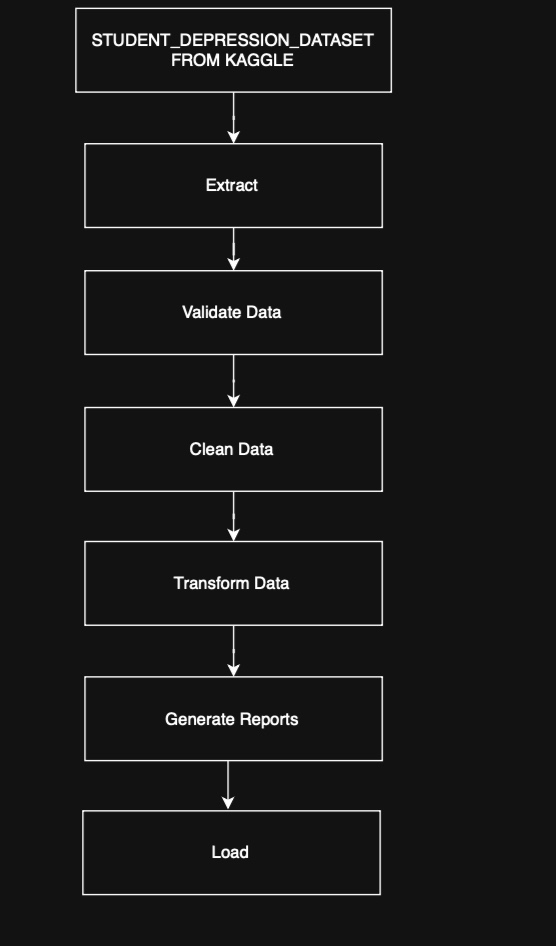

#Step 5 – Build the Extract Function

In [77]:
import pandas as pd
import os

In [78]:
def extract():
    stud_dep = pd.read_csv("/content/raw_data/Student Depression Dataset.csv")
    print(stud_dep)
    return stud_dep

#Step 6 – Build the Transform Function

In [79]:
def transform(stud_dep):
 # 1. Remove duplicate records
  stud_dep = stud_dep.drop_duplicates()

 # 2. Handle missing values
  stud_dep = stud_dep.dropna()

 # 3. Remove unwanted column
  if "id" in stud_dep.columns:
      stud_dep = stud_dep.drop(columns=["id"])

# 4. Standardize column names
  stud_dep.columns = stud_dep.columns.str.strip().str.lower().str.replace(" ", "_")

# 5. Standardize text values
  for col in stud_dep.select_dtypes(include="object").columns:
        stud_dep[col] = stud_dep[col].str.strip()
# 6. Remove invalid age values
  if "age" in stud_dep.columns:
        stud_dep = stud_dep[(stud_dep["age"] >= 15) & (stud_dep["age"] <= 100)]

# 7. Sort records by age
  if "age" in stud_dep.columns:
        stud_dep = stud_dep.sort_values(by="age")

# 8. Create a depression category
  if "depression" in stud_dep.columns:
        stud_dep["depression_category"] = stud_dep["depression"].map({
            0: "No",
            1: "Yes"
        })
        return stud_dep



#Step 7 – Generate Reports and
#step 8 load

In [80]:
def load(data,dep_risk):
  def load(clean_data,summary,risk_report):
    file_path='/content/reports/cleaned_data.csv'
    if not os.path.exists(file_path):
      clean_data.to_csv(file_path,mode='w',header=True,index=False)
    else:
        clean_data.to_csv(file_path,mode='a',header=True,index=False)
    dep_risk.to_csv("/content/reports/depression_risk.csv")




#Step 9 – Build the Pipeline

In [81]:
def data_pipeline():
  raw = extract()
  df = transform(raw)
  dep_risk = df["academic_pressure"].value_counts().reset_index()
  dep_risk.columns=['academic_pressure','sleep_duration']
  load(df,dep_risk)
  return df

In [82]:
data_pipeline()

           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0                0.

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category
26320,Female,18.0,Rajkot,Student,5.0,0.0,8.91,3.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,10.0,2.0,Yes,1,Yes
26318,Male,18.0,Surat,Student,5.0,0.0,7.83,5.0,0.0,More than 8 hours,Moderate,Class 12,Yes,8.0,5.0,Yes,1,Yes
3202,Male,18.0,Vasai-Virar,Student,4.0,0.0,8.70,5.0,0.0,Less than 5 hours,Moderate,Class 12,Yes,2.0,4.0,No,1,Yes
14770,Male,18.0,Varanasi,Student,4.0,0.0,9.19,5.0,0.0,7-8 hours,Healthy,Class 12,Yes,12.0,3.0,Yes,1,Yes
14769,Female,18.0,Kanpur,Student,1.0,0.0,7.27,5.0,0.0,Less than 5 hours,Healthy,Class 12,No,7.0,5.0,No,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4386,Female,51.0,Bhopal,Student,2.0,0.0,8.26,3.0,0.0,Less than 5 hours,Moderate,MBBS,Yes,5.0,5.0,Yes,0,No
13499,Male,54.0,Agra,Student,5.0,0.0,9.60,2.0,0.0,More than 8 hours,Unhealthy,B.Ed,Yes,9.0,3.0,Yes,0,No
14819,Female,56.0,Ludhiana,Student,3.0,0.0,7.94,5.0,0.0,5-6 hours,Unhealthy,BSc,No,1.0,5.0,Yes,0,No
2909,Female,58.0,Chennai,Student,4.0,0.0,8.58,1.0,0.0,7-8 hours,Healthy,Class 12,No,4.0,4.0,No,0,No
